# Correlation Analysis
This notebook analyzes the correlations between the dataset features and the target variable (`has_heart_disease`). It visualizes the relationships to help understand which factors are most predictive.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure current working directory is the project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("../../")

INPUT_PATH = "data/processed/cleaned_data.csv"
TARGET = "has_heart_disease"

df = pd.read_csv(INPUT_PATH)
print(f"Loaded {len(df)} rows from {INPUT_PATH}")

Loaded 9000 rows from data/processed/cleaned_data.csv


### Top 10 Most Correlated Features
Because we are now using the full dataset (28 features), a full correlation matrix would be visually overwhelming. Here we calculate and plot the 10 features most strongly correlated (positively or negatively) with heart disease.

Top 10 correlated features:
max_heart_rate_achieved: -0.581
exercise_induced_angina: 0.445
st_depression: 0.357
age: 0.291
ldl: 0.267
hdl: -0.252
resting_bp_systolic: 0.249
exercise_minutes_per_week: -0.248
hba1c: 0.226
bmi: 0.213


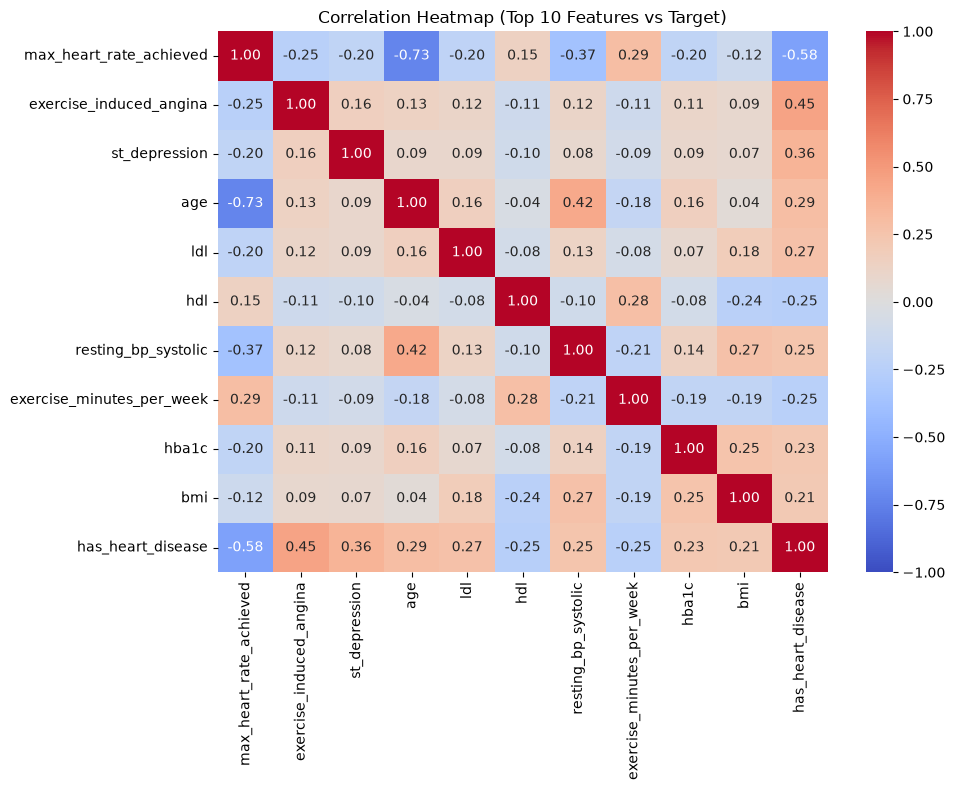

In [ ]:
# Calculate correlations with the target
correlations = df.corr()[TARGET].drop(TARGET)

# Get top 10 absolute correlations
top_features = correlations.abs().sort_values(ascending=False).head(10).index.tolist()

print("Top 10 correlated features:")
for feat in top_features:
    print(f"{feat}: {correlations[feat]:.3f}")
    
# Create subset for heatmap
cols_to_plot = top_features + [TARGET]
corr_matrix = df[cols_to_plot].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Top 10 Features vs Target)')
plt.tight_layout()
plt.show()